# Support Vector Machine

# Model

### imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

### Dataset Prep

In [10]:
df = pd.read_csv("../Data/coral_regime.csv", low_memory=False)
df = df.replace('nd', pd.NA)

num_cols = ['Latitude_Degrees','Longitude_Degrees','Depth_m','Percent_Cover','Bleaching_Level',
            'Percent_Bleaching','ClimSST','Temperature_Kelvin','Temperature_Mean',
            'Temperature_Minimum','Temperature_Maximum','Temperature_Kelvin_Standard_Deviation',
            'Windspeed','SSTA','SSTA_Mean','SSTA_Maximum','SSTA_Minimum',
            'TSA','TSA_Mean','TSA_Maximum','TSA_Minimum']

df = df[[c for c in num_cols if c in df.columns]]
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['Percent_Bleaching','Percent_Cover'])

In [11]:
df['Bleaching_Class'] = pd.cut(df['Percent_Bleaching'], bins=[-1,20,50,100], labels=['Low','Medium','High'])
X = df.drop(['Percent_Bleaching','Bleaching_Class'], axis=1)
y = df['Bleaching_Class']


In [12]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Bleaching_Level']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


### Dataset Splitting

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Smote

In [14]:
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

### Training

In [15]:
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_bal, y_train_bal)
y_pred = svm.predict(X_test)

### Model Stats

In [16]:
print("Accuracy:", round(accuracy_score(y_test, y_pred),4))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8024
              precision    recall  f1-score   support

        High       0.15      0.63      0.24        71
         Low       0.99      0.81      0.89      4353
      Medium       0.10      0.62      0.18       111

    accuracy                           0.80      4535
   macro avg       0.41      0.69      0.44      4535
weighted avg       0.95      0.80      0.86      4535



### Model Confusion Matrix

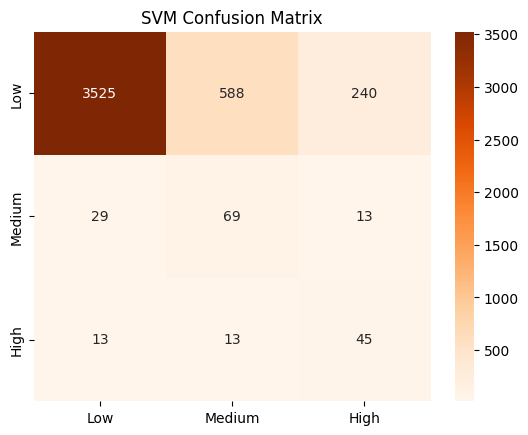

In [17]:
cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.title("SVM Confusion Matrix")
plt.show()


# SVM - Hyperparameter Tuning


## SVM_PCA

In [35]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

svm_pca = Pipeline([
    ('pca', PCA(n_components=0.95)),   # Keep 95% variance
    ('svm', SVC(C=10, kernel='rbf', gamma='scale', probability=True))
])

svm_pca.fit(X_train_bal, y_train_bal)
y_pred_pca = svm_pca.predict(X_test)

print("\nSVM with PCA Accuracy:", round(accuracy_score(y_test, y_pred_pca), 4))
print(classification_report(y_test, y_pred_pca, zero_division=0))



SVM with PCA Accuracy: 0.8512
              precision    recall  f1-score   support

        High       0.18      0.58      0.27        71
         Low       0.99      0.86      0.92      4353
      Medium       0.13      0.59      0.22       111

    accuracy                           0.85      4535
   macro avg       0.43      0.68      0.47      4535
weighted avg       0.95      0.85      0.89      4535



## Optimized Fast SVM (HalvingGridSearchCV)


n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 1632
max_resources_: 52233
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 50
n_resources: 1632
Fitting 3 folds for each of 50 candidates, totalling 150 fits
----------
iter: 1
n_candidates: 25
n_resources: 3264
Fitting 3 folds for each of 25 candidates, totalling 75 fits
----------
iter: 2
n_candidates: 13
n_resources: 6528
Fitting 3 folds for each of 13 candidates, totalling 39 fits
----------
iter: 3
n_candidates: 7
n_resources: 13056
Fitting 3 folds for each of 7 candidates, totalling 21 fits
----------
iter: 4
n_candidates: 4
n_resources: 26112
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 5
n_candidates: 2
n_resources: 52224
Fitting 3 folds for each of 2 candidates, totalling 6 fits

✅ Best Parameters Found:
{'C': 10, 'class_weight': 'balanced', 'gamma': 0.2, 'kernel': 'rbf'}

🎯 Tuned SVM Accuracy: 0.944

Detailed Classification Report:

      

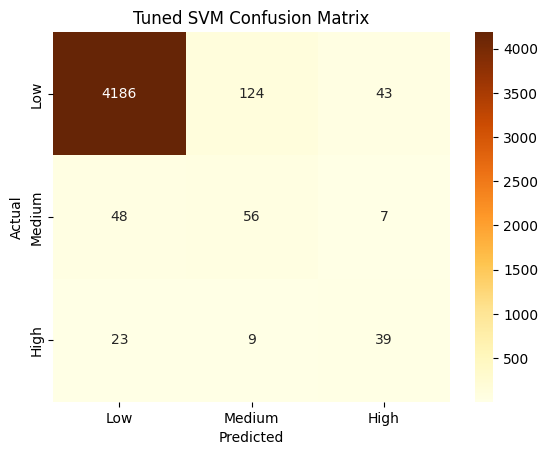

In [ ]:

from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define SVM model
svm = SVC(probability=True, random_state=42)

# Focused parameter grid (fast & effective)
param_grid = {
    'C': [0.5, 1, 2, 5, 10],
    'gamma': ['scale', 0.01, 0.05, 0.1, 0.2],
    'kernel': ['rbf'],
    'class_weight': [None, 'balanced']
}

# Successive halving grid search
halving_search = HalvingGridSearchCV(
    svm,
    param_grid,
    factor=2,         # Reduces candidates each iteration
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit on SMOTE-balanced training data
halving_search.fit(X_train_bal, y_train_bal)

# -------------------------------
# 🔹 Display Best Results
# -------------------------------
print("\n✅ Best Parameters Found:")
print(halving_search.best_params_)

best_svm = halving_search.best_estimator_
y_pred_best = best_svm.predict(X_test)

acc_tuned = round(accuracy_score(y_test, y_pred_best), 4)

print(f"\n🎯 Tuned SVM Accuracy: {acc_tuned}")
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred_best, zero_division=0))

# -------------------------------
# 🔹 Confusion Matrix
# -------------------------------
cm_tuned = confusion_matrix(y_test, y_pred_best, labels=['Low','Medium','High'])
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
plt.title("Tuned SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



## SVM Model Comparison



📈 SVM Accuracy Comparison:
                 Model  Accuracy
0         Baseline SVM    0.8024
1      SVM + PCA (95%)    0.8512
2  Tuned SVM (Halving)    0.9440


C:\Windows\Temp\ipykernel_8024\2031292714.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=svm_comparison, palette='Oranges_r')


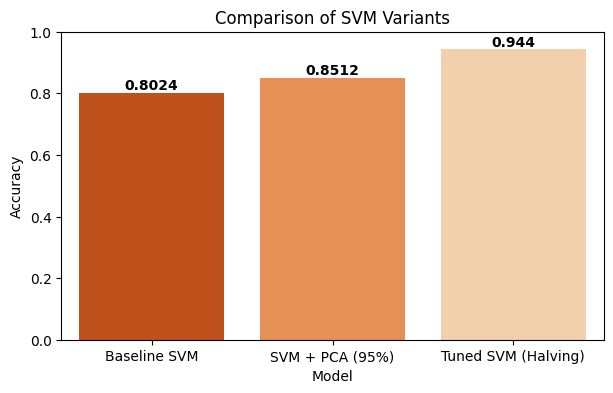

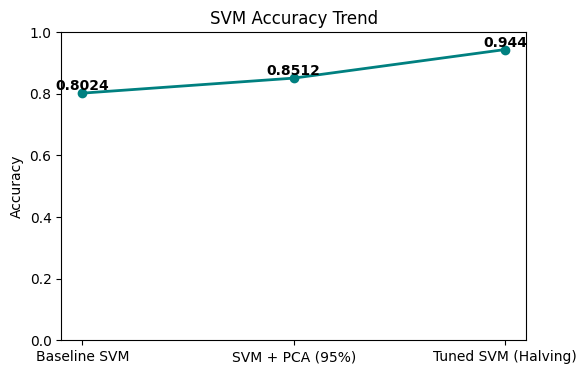

In [ ]:

baseline_acc = round(accuracy_score(y_test, y_pred), 4)
pca_acc = round(accuracy_score(y_test, y_pred_pca), 4)
tuned_acc = round(accuracy_score(y_test, y_pred_best), 4)

# Create comparison table
svm_comparison = pd.DataFrame({
    'Model': ['Baseline SVM', 'SVM + PCA (95%)', 'Tuned SVM (Halving)'],
    'Accuracy': [baseline_acc, pca_acc, tuned_acc]
})

print("\n📈 SVM Accuracy Comparison:")
print(svm_comparison)

# Bar chart
plt.figure(figsize=(7, 4))
sns.barplot(x='Model', y='Accuracy', data=svm_comparison, palette='Oranges_r')
plt.title("Comparison of SVM Variants")
plt.ylim(0, 1)
for i, v in enumerate(svm_comparison['Accuracy']):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.show()

# Optional trend line
plt.figure(figsize=(6, 4))
plt.plot(svm_comparison['Model'], svm_comparison['Accuracy'],
         marker='o', color='teal', linewidth=2)
plt.title("SVM Accuracy Trend")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(svm_comparison['Accuracy']):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.show()


In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import joblib

# Save model name and metrics
model_name = "Logistic Regression"
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_mat = confusion_matrix(y_test, y_pred)

results = {
    "Model": "SVM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ConfusionMatrix": confusion_matrix(y_test, y_pred).tolist()
}
joblib.dump(results, "svm_results.pkl")


['svm_results.pkl']

In [44]:
y_pred_svm_best = best_svm.predict(X_test)

In [45]:
tuned_svm_results = {
    "Model": "SVM (Tuned - HalvingGridSearchCV)",
    "Accuracy": accuracy_score(y_test, y_pred_svm_best),
    "Precision": precision_score(y_test, y_pred_svm_best, average='weighted'),
    "Recall": recall_score(y_test, y_pred_svm_best, average='weighted'),
    "F1": f1_score(y_test, y_pred_svm_best, average='weighted'),
    "ConfusionMatrix": confusion_matrix(y_test, y_pred_svm_best, labels=['Low','Medium','High']).tolist()
}
joblib.dump(tuned_svm_results, "svm_tuned_results.pkl")

['svm_tuned_results.pkl']